<a href="https://colab.research.google.com/github/saradom11/Simulacion-II/blob/main/Codigo_Metropolis_Hastings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align:center; background-color:#F3E5F5; padding:18px; border-radius:12px;">

<font face="Georgia" size="6" color="#6A1B9A"><b>Ejercicio: Algoritmo Metropolis-Hastings</b></font>

**Materia:** Simulación II

**Alumna:** Arredondo Domínguez Sara Itzel

</div>


---

<font face="Georgia" size="5" color="#7B1FA2"><b>1. Planteamiento del problema</b></font>

<font face="Arial" size="4" color="#4A235A">

Utilizaremos el algoritmo **Metropolis-Hastings** para simular la función de densidad bidimensional dada en clase:

</font>

$
f(x_1,x_2)=C\,e^{-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}}
$

<font face="Arial" size="4">

donde $C$ es una constante de normalización.

</font>

<font face="Arial" size="4" color="#6A1B9A"><b>Objetivo:</b></font>

<font face="Arial" size="4">

Generar, mediante una cadena de Markov, observaciones $(x_1,x_2)$ que sigan la distribución definida por esta función.

</font>


In [29]:
# NumPy permite trabajar con arreglos, operaciones matemáticas y generación de números aleatorios
import numpy as np

# Matplotlib se utiliza para construir las gráficas
import matplotlib.pyplot as plt


---

<font face="Georgia" size="5" color="#7B1FA2"><b>2. No necesitamos conocer \(C\)</b></font>

Como Metropolis-Hastings utiliza el cociente

$
\frac{f(Y)}{f(X_t)},
$

tenemos:

$
\frac{Ce^{-g(Y)}}{Ce^{-g(X_t)}}
\Rightarrow
\frac{e^{-g(Y)}}{e^{-g(X_t)}}.
$

La constante $C$ se cancela. Por esta razón podemos trabajar directamente con la función proporcional a la densidad, sin calcular la constante.

<font face="Arial" size="4" color="#6A1B9A"><b>Idea importante:</b></font> para Metropolis-Hastings basta conocer la función objetivo hasta una constante multiplicativa.


In [30]:
# ---------------------------------------------------------
# Definición de la función objetivo
# ---------------------------------------------------------
def f(x1, x2):
    # Calculamos el exponente de la función
    exponent = -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2

    # np.exp() calcula la función exponencial e^(exponente)
    return np.exp(exponent)


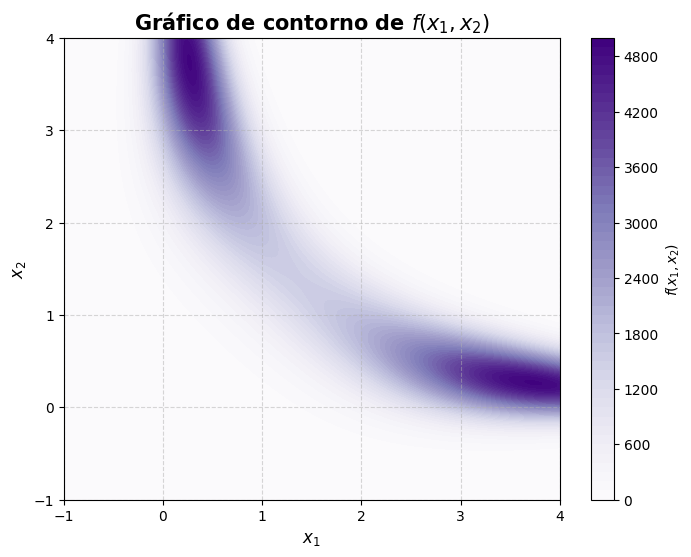

In [31]:
# ---------------------------------------------------------
# Malla de puntos para x1 y x2
# ---------------------------------------------------------

# linspace genera 400 valores igualmente espaciados entre -1 y 4
x1 = np.linspace(-1, 4, 400)
x2 = np.linspace(-1, 4, 400)

# meshgrid convierte los vectores x1 y x2 en matrices que permiten evaluar la función sobre toda la región
X1, X2 = np.meshgrid(x1, x2)

# Evaluamos la función en cada punto de la malla
Z = f(X1, X2)

# ---------------------------------------------------------
# Gráfica de contorno
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# contourf crea regiones rellenas según el valor de Z
# cmap='Purples' utiliza una escala de colores morados
contour = plt.contourf(X1, X2, Z, levels=50, cmap='Purples')

plt.colorbar(contour, label='$f(x_1, x_2)$')
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Gráfico de contorno de $f(x_1,x_2)$',fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


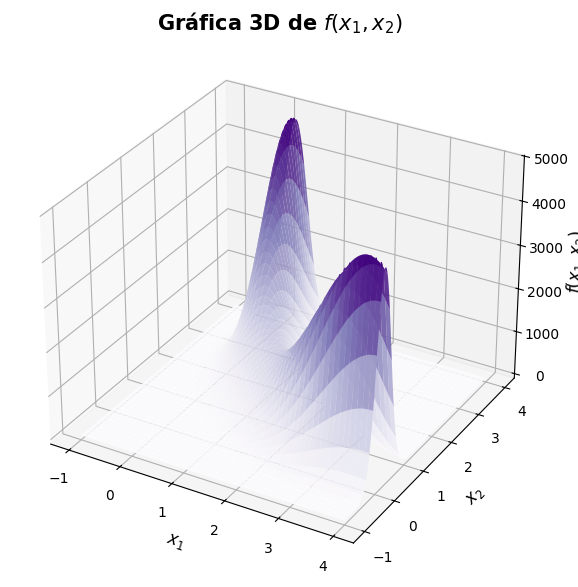

In [32]:
# ---------------------------------------------------------
# Gráfica tridimensional de la función
# ---------------------------------------------------------

# Creamos una figura y un eje 3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# plot_surface representa la superficie Z=f(x1,x2)
surf = ax.plot_surface(X1, X2, Z,cmap='Purples',edgecolor='none',alpha=0.9)

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_zlabel('$f(x_1,x_2)$', fontsize=12)
ax.set_title('Gráfica 3D de $f(x_1,x_2)$',fontsize=15, fontweight='bold')
plt.show()


In [33]:
# ---------------------------------------------------------
# Parámetros del algoritmo
# ---------------------------------------------------------

N = 10000          # Número de simulaciones
sigma = 1.0        # Desviación estándar de la propuesta normal

# Punto inicial de la cadena: X_0 = (0,0)
x = np.array([0.0, 0.0])

# Matriz de N filas y 2 columnas
# Cada fila almacena un punto (x1,x2) de la cadena
muestra = np.zeros((N, 2))

# Contador de propuestas aceptadas
aceptados = 0


In [34]:
# ---------------------------------------------------------
# Función objetivo para un punto (x1,x2)
# ---------------------------------------------------------
def funcion(x):
    # x es un arreglo de dos componentes
    x1 = x[0]
    x2 = x[1]

    # Evaluamos la misma función que ya definín
    return np.exp(
        -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    )


---

<font face="Georgia" size="5" color="#7B1FA2"><b>3. Algoritmo Metropolis-Hastings</b></font>

El procedimiento utilizado en el código es:

**1. Inicializar**

$
X_0=(0,0), \qquad t=0
$

**2. Repetir para cada iteración:**

- Generar un candidato:
$
Y=X_t+\varepsilon,
\qquad
\varepsilon\sim N(0,\sigma^2I)
$

- Calcular la probabilidad de aceptación:
$\alpha(X_t,Y)=\min\left(1,\frac{f(Y)}{f(X_t)}\right)$

- Generar:
$
U\sim U(0,1)
$

Si $U\leq\alpha$, aceptar:
$
X_{t+1}=Y.
$

En otro caso:
$
X_{t+1}=X_t.
$

- Guardar el punto obtenido y continuar con la siguiente iteración.

<font face="Arial" size="4" color="#6A1B9A"><b>Nota:</b></font> como la distribución propuesta es simétrica, el cociente de las funciones de propuesta $q$ se cancela.


In [35]:
# ---------------------------------------------------------
# Algoritmo Metropolis-Hastings
# ---------------------------------------------------------

for i in range(N):

    # 1. Generar un candidato Y
    # np.random.normal(0, sigma, 2) genera dos valores normales con media 0 y desviación sigma
    y = x + np.random.normal(0, sigma, 2)

    # 2. Calcular la probabilidad de aceptación
    # min(1, ...) garantiza que alpha nunca sea mayor que 1
    alpha = min(1, funcion(y) / funcion(x))

    # 3. Generar U ~ Uniforme(0,1)
    U = np.random.uniform(0, 1)

    # 4. Decidir si aceptamos el candidato
    if U <= alpha:
        x = y
        aceptados += 1

    # 5. Guardar el estado actual de la cadena
    muestra[i] = x

print("Simulación")
print("------------------------------------------------")
print("Propuestas aceptadas:", aceptados)
print("Tasa de aceptación:", aceptados / N)


Simulación
------------------------------------------------
Propuestas aceptadas: 2979
Tasa de aceptación: 0.2979


In [36]:
# ---------------------------------------------------------
# Media de las muestras
# ---------------------------------------------------------

# np.mean calcula el promedio
# axis=0 indica que queremos promediar cada columna por separado
# columna 0 -> x1
# columna 1 -> x2
media = np.mean(muestra, axis=0)

print("Media estimada de x1:", media[0])
print("Media estimada de x2:", media[1])


Media estimada de x1: 1.7091405978447234
Media estimada de x2: 2.0455880711471552


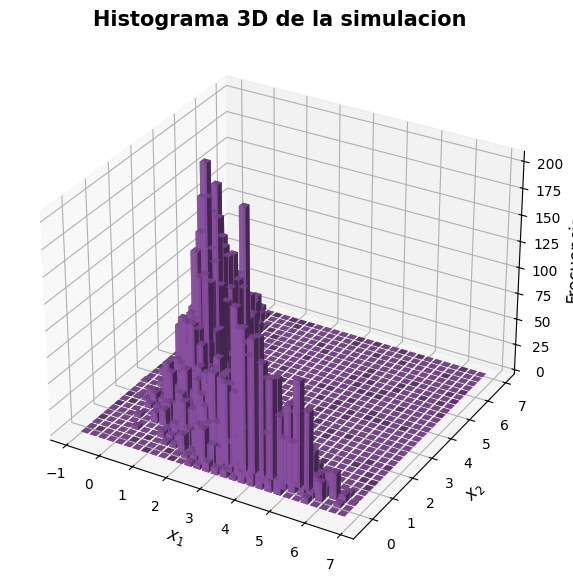

In [37]:
# ---------------------------------------------------------
# Histograma bidimensional de las muestras
# ---------------------------------------------------------

# histogram2d cuenta cuántos puntos caen dentro de cada intervalo de x1 y x2
frecuencia, x_edges, y_edges = np.histogram2d(muestra[:, 0],muestra[:, 1],bins=30)

# Calculamos el centro de cada intervalo
x_centros = (x_edges[:-1] + x_edges[1:]) / 2
y_centros = (y_edges[:-1] + y_edges[1:]) / 2

# meshgrid construye las coordenadas para cada barra
X, Y = np.meshgrid(x_centros, y_centros)

# ---------------------------------------------------------
# Gráfica 3D del histograma
# ---------------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# ravel() convierte las matrices X y Y en vectores
# bar3d dibuja una barra en cada combinación (x1,x2)
ax.bar3d(X.ravel(), Y.ravel(), np.zeros(X.size),0.2,0.2,frecuencia.T.ravel(),color="#9B59B6",alpha=0.85)
ax.set_xlabel("$x_1$", fontsize=12)
ax.set_ylabel("$x_2$", fontsize=12)
ax.set_zlabel("Frecuencia", fontsize=12)
ax.set_title("Histograma 3D de la simulacion",fontsize=15, fontweight='bold')
plt.show()


---

<font face="Georgia" size="5" color="#7B1FA2"><b>4. Tasa de aceptación</b></font>

La tasa de aceptación indica qué proporción de las propuestas generadas por el algoritmo fue aceptada:

$\text{Tasa de aceptación}=\frac{\text{número de propuestas aceptadas}}
{\text{número total de propuestas}} $

Este valor permite evaluar el comportamiento del algoritmo. Si la propuesta es demasiado grande, pueden producirse muchos rechazos; si es demasiado pequeña, la cadena puede avanzar lentamente.


In [38]:
# Calculamos nuevamente la tasa de aceptación
tasa_aceptacion = aceptados / N

print(f"Tasa de aceptación = {tasa_aceptacion:.4f}")
print(f"Porcentaje de aceptación = {100*tasa_aceptacion:.2f}%")


Tasa de aceptación = 0.2979
Porcentaje de aceptación = 29.79%


---

<font face="Georgia" size="5" color="#7B1FA2"><b>5. Comportamiento de la cadena</b></font>

Para verificar cómo se mueve la cadena, graficamos los valores de $x_1$ y $x_2$ contra el número de iteración.


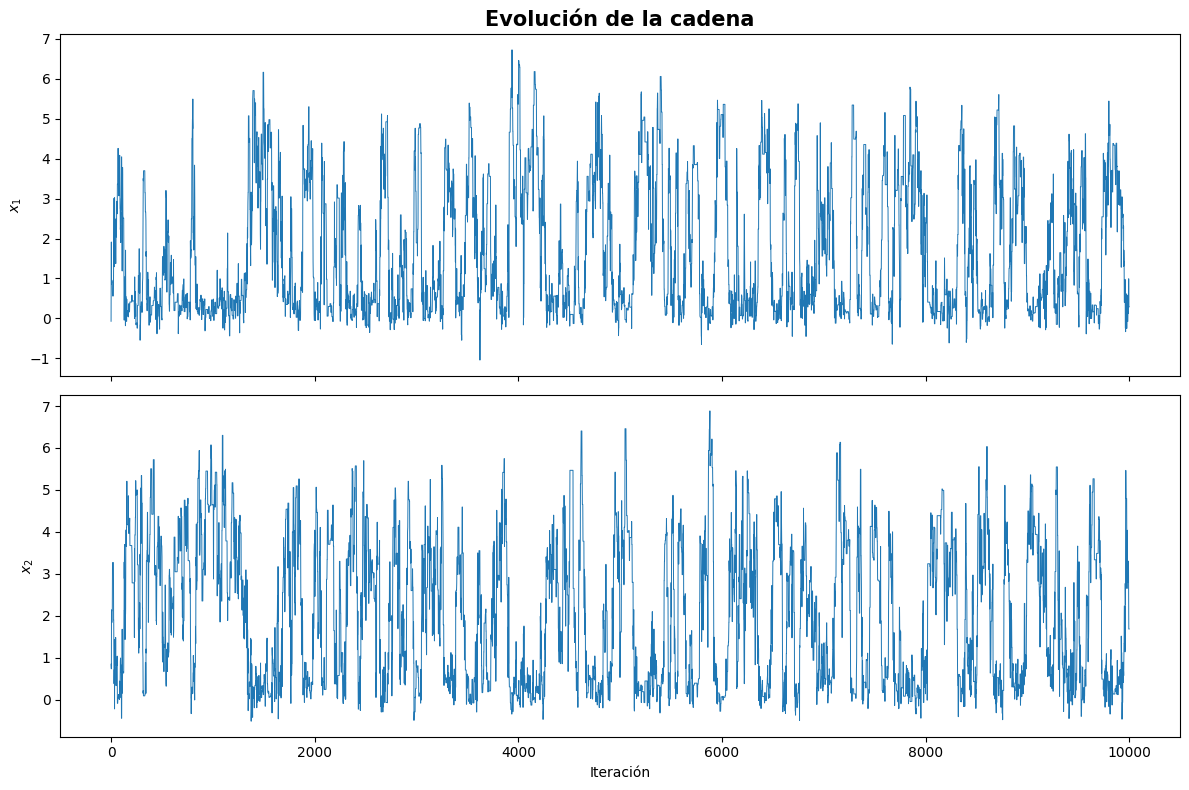

In [39]:
# ---------------------------------------------------------
# Trazas de x1 y x2
# ---------------------------------------------------------

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Primera gráfica: valores de x1
ax[0].plot(muestra[:, 0], linewidth=0.7)
ax[0].set_ylabel("$x_1$")
ax[0].set_title("Evolución de la cadena", fontsize=15, fontweight="bold")

# Segunda gráfica: valores de x2
ax[1].plot(muestra[:, 1], linewidth=0.7)
ax[1].set_ylabel("$x_2$")
ax[1].set_xlabel("Iteración")

plt.tight_layout()
plt.show()


---

<font face="Georgia" size="5" color="#7B1FA2"><b>6. Nube de puntos de la simulación</b></font>

La siguiente gráfica muestra directamente los puntos $(x_1,x_2)$ obtenidos. Esto permite observar la región del plano que visita la cadena con mayor frecuencia.


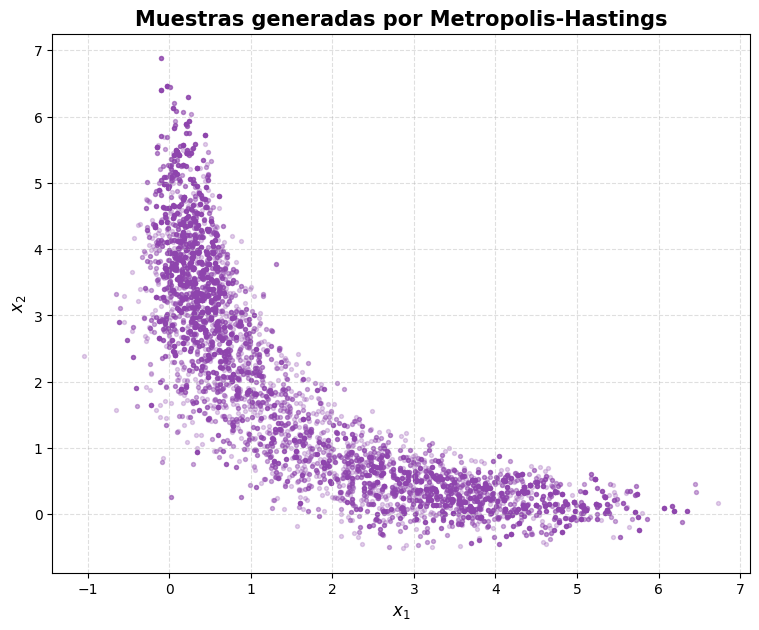

In [40]:
# Gráfica de dispersión de las muestras
plt.figure(figsize=(9, 7))

plt.scatter(muestra[:, 0],muestra[:, 1],s=8,alpha=0.25,color="#8E44AD")

plt.xlabel("$x_1$", fontsize=12)
plt.ylabel("$x_2$", fontsize=12)
plt.title("Muestras generadas por Metropolis-Hastings",fontsize=15, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


---

<font face="Georgia" size="5" color="#7B1FA2"><b>7. Comparación entre la función y las muestras</b></font>

Finalmente, superponemos las muestras sobre la función objetivo. Si el algoritmo está funcionando correctamente, las muestras deben concentrarse en las regiones donde la función presenta valores más altos.


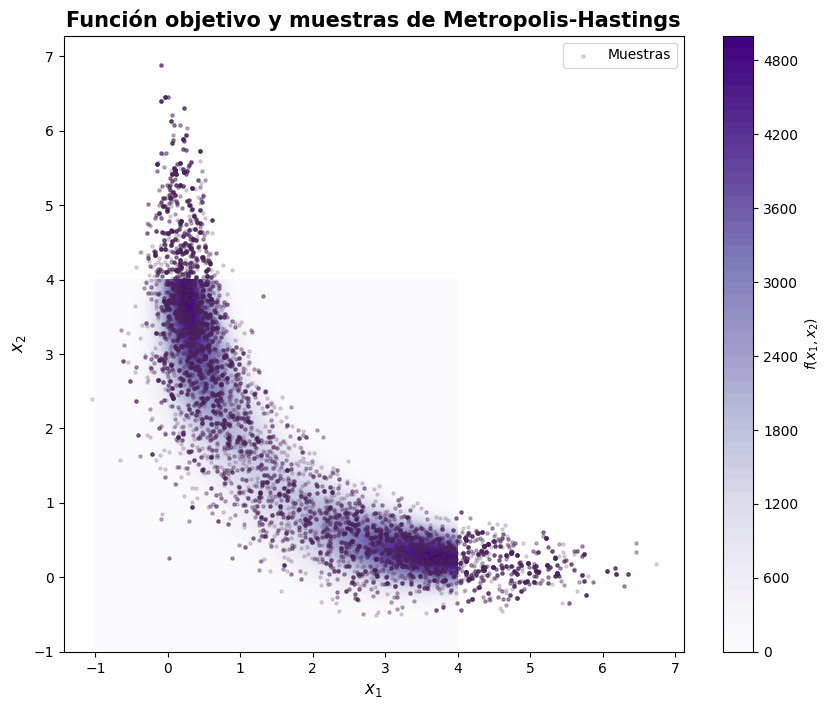

In [41]:
# ---------------------------------------------------------
# Función objetivo + muestras generadas
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

# Mapa de contorno de la función
contorno = plt.contourf(X1, X2, Z,levels=50,cmap="Purples")
plt.colorbar(contorno, label="$f(x_1,x_2)$")

# Muestras obtenidas por Metropolis-Hastings
plt.scatter(muestra[:, 0],muestra[:, 1],s=5,alpha=0.18,color="#4A235A",label="Muestras")

plt.xlabel("$x_1$", fontsize=12)
plt.ylabel("$x_2$", fontsize=12)
plt.title("Función objetivo y muestras de Metropolis-Hastings",fontsize=15, fontweight="bold")
plt.legend()
plt.show()


<font face="Georgia" size="5" color="#7B1FA2"><b>8. Interpretación de resultados</b></font>

<font face="Arial" size="4">

El algoritmo comenzó en el punto $X_0=(0,0)$ y, en cada iteración, propuso un nuevo punto utilizando una distribución normal.

La decisión de aceptar o rechazar cada propuesta depende de la razón entre la función evaluada en el nuevo punto y en el punto actual.

La matriz <code>muestra</code> contiene finalmente los puntos visitados por la cadena. Las gráficas permiten comprobar que la simulación se concentra en las regiones de mayor valor de la función objetivo.

La media calculada con <code>np.mean(muestra, axis=0)</code> proporciona una estimación de los valores medios de $x_1$ y $x_2$ a partir de la muestra simulada.

</font>


---
<div style="background-color:#EDE7F6; padding:20px; border-left:7px solid #7B1FA2; border-radius:10px;">

<font face="Georgia" size="5" color="#6A1B9A"><b>9. Solución</b></font>

<font face="Arial" size="4">

La solución del ejercicio consiste en la muestra

$
\boxed{\{(x_1^{(i)},x_2^{(i)})\}_{i=1}^{N}}
$

generada mediante el algoritmo Metropolis-Hastings.

A partir de esta muestra se obtuvo:

- la tasa de aceptación;
- la media estimada de $x_1$ y $x_2$;
- las trazas de la cadena;
- el histograma bidimensional;
- y la comparación gráfica entre la función objetivo y los puntos simulados.

Por lo tanto, el algoritmo permite simular la distribución bidimensional sin necesidad de calcular explícitamente la constante de normalización $C$.

</font>
</div>
